# Notebook 1: Exploratory Data Analysis
**Goal:** Understand the Olist dataset structure, assess data quality,
and uncover patterns in customer purchasing behavior that will inform
our churn prediction model.

**Business question we are answering:** Who are our customers, how do 
they behave, and what early signals suggest a customer is about to stop buying?

**Datasets:** Brazilian E-Commerce Public Dataset by Olist (sourced from Kaggle).
Contains ~100,000 orders from 2016 to 2018 across multiple tables.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries ready.")

In [ ]:
orders    = pd.read_csv('../data/raw/olist_orders_dataset.csv')
items     = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
payments  = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
reviews   = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products  = pd.read_csv('../data/raw/olist_products_dataset.csv')

tables = {
    'orders': orders, 'items': items,
    'customers': customers, 'payments': payments,
    'reviews': reviews, 'products': products
}

print(f"{'Table':<12} {'Rows':>8} {'Columns':>9}")
print("-" * 32)
for name, df in tables.items():
    print(f"{name:<12} {len(df):>8,} {df.shape[1]:>9}")

In [ ]:
orders.head()

In [ ]:
orders.info()

In [ ]:
orders.isnull().sum()

### Data Cleaning

---

Problems identified:
1. Date columns are text — need to convert to datetime
2. Dataset contains incomplete/canceled orders — need to filter to delivered only
3. orders table uses the wrong customer ID — need to merge in customer_unique_id

In [ ]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("Dtypes after conversion: ")
print(orders[date_cols].dtypes)


In [ ]:
orders['order_status'].value_counts()

In [ ]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"Before: {len(orders):,} orders")
print(f"After: {len(orders_delivered):,} orders")
print(f"Removed: {len(orders) - len(orders_delivered):,} incomplete orders")

In [ ]:
print("customer_id unique count in orders:          ", orders_delivered['customer_id'].nunique())
print("customer_unique_id unique count in customers:", customers['customer_unique_id'].nunique())

In [ ]:
orders_enriched = orders_delivered.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state']],
    on='customer_id',
    how='left'
)

print(f"Rows before merge: {len(orders_delivered):,}")
print(f"Rows after merge:  {len(orders_enriched):,}")
print(f"Columns added: {[c for c in orders_enriched.columns if c not in orders_delivered.columns]}")
print(f"Missing customer_unique_id: {orders_enriched['customer_unique_id'].isnull().sum()}")

In [ ]:
order_values = (
    payments
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
    .rename(columns={'payment_value': 'order_value'})
)

orders_enriched = orders_enriched.merge(order_values, on='order_id', how='left')

print(f"Missing order_value: {orders_enriched['order_value'].isnull().sum()}")
print(f"\nOrder value summary:")
print(orders_enriched['order_value'].describe().round(2))

In [ ]:
orders_enriched.to_csv('../data/processed/orders_enriched.csv', index=False)

print(f"Saved to data/processed/orders_enriched.csv")
print(f"Final shape: {orders_enriched.shape}")
print(f"Columns: {list(orders_enriched.columns)}")

### Defining Target Value


**Rule**: a customer has churned if they have not placed any order in the last 90 days.

In [26]:
snapshot_date = orders_enriched['order_purchase_timestamp'].max() - pd.Timedelta(days=1)

print(f"Dataset date range:")
print(f"  Earliest order: {orders_enriched['order_purchase_timestamp'].min().date()}")
print(f"  Latest order:   {orders_enriched['order_purchase_timestamp'].max().date()}")
print(f"  Snapshot date:  {snapshot_date.date()}")

Dataset date range:
  Earliest order: 2016-09-15
  Latest order:   2018-08-29
  Snapshot date:  2018-08-28


In [27]:
customer_stats = (
    orders_enriched
    .groupby('customer_unique_id')
    .agg(
        last_purchase = ('order_purchase_timestamp', 'max'),
        first_purchase = ('order_purchase_timestamp', 'min'),
        total_orders = ('order_id', 'count'),
        total_revenue = ('order_value', 'sum')
    )
    .reset_index()
)

customer_stats['order_value'] = customer_stats['order_value'] if 'order_value' in customer_stats.columns else customer_stats.get('total_revenue', 0)

print(f"Unique customers: {len(customer_stats):,}")
print(customer_stats.head())

Unique customers: 93,358
                 customer_unique_id       last_purchase      first_purchase  \
0  0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10 10:56:27 2018-05-10 10:56:27   
1  0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07 11:11:27 2018-05-07 11:11:27   
2  0000f46a3911fa3c0805444483337064 2017-03-10 21:05:03 2017-03-10 21:05:03   
3  0000f6ccb0745a6a4b88665a16c9f078 2017-10-12 20:29:41 2017-10-12 20:29:41   
4  0004aac84e0df4da2b147fca70cf8255 2017-11-14 19:45:42 2017-11-14 19:45:42   

   total_orders  total_revenue  order_value  
0             1         141.90       141.90  
1             1          27.19        27.19  
2             1          86.22        86.22  
3             1          43.62        43.62  
4             1         196.89       196.89  


In [28]:
customer_stats['days_since_last_purchase'] = (
    snapshot_date - customer_stats['last_purchase']
).dt.days

print("Days since last purchase — summary:")
print(customer_stats['days_since_last_purchase'].describe().round(1))

Days since last purchase — summary:
count    93358.0
mean       235.9
std        152.6
min         -1.0
25%        112.0
50%        217.0
75%        344.0
max        712.0
Name: days_since_last_purchase, dtype: float64


In [29]:
CHURN_DAYS = 90

customer_stats['churned'] = (
    customer_stats['days_since_last_purchase'] > CHURN_DAYS
).astype(int)

total    = len(customer_stats)
churned  = customer_stats['churned'].sum()
active   = total - churned

print(f"Churn threshold: {CHURN_DAYS} days")
print(f"Total customers: {total:,}")
print(f"Churned  (1):    {churned:,}  —  {churned/total:.1%}")
print(f"Active   (0):    {active:,}  —  {active/total:.1%}")

Churn threshold: 90 days
Total customers: 93,358
Churned  (1):    74,630  —  79.9%
Active   (0):    18,728  —  20.1%


In [30]:
customer_stats['total_revenue'] = customer_stats['total_revenue'].fillna(0)

customer_stats.to_csv('../data/processed/customer_churn_labels.csv', index=False)

print(f"Saved. Shape: {customer_stats.shape}")
print(f"Columns: {list(customer_stats.columns)}")

Saved. Shape: (93358, 8)
Columns: ['customer_unique_id', 'last_purchase', 'first_purchase', 'total_orders', 'total_revenue', 'order_value', 'days_since_last_purchase', 'churned']


### Exploratory Data Analysis (EDA)

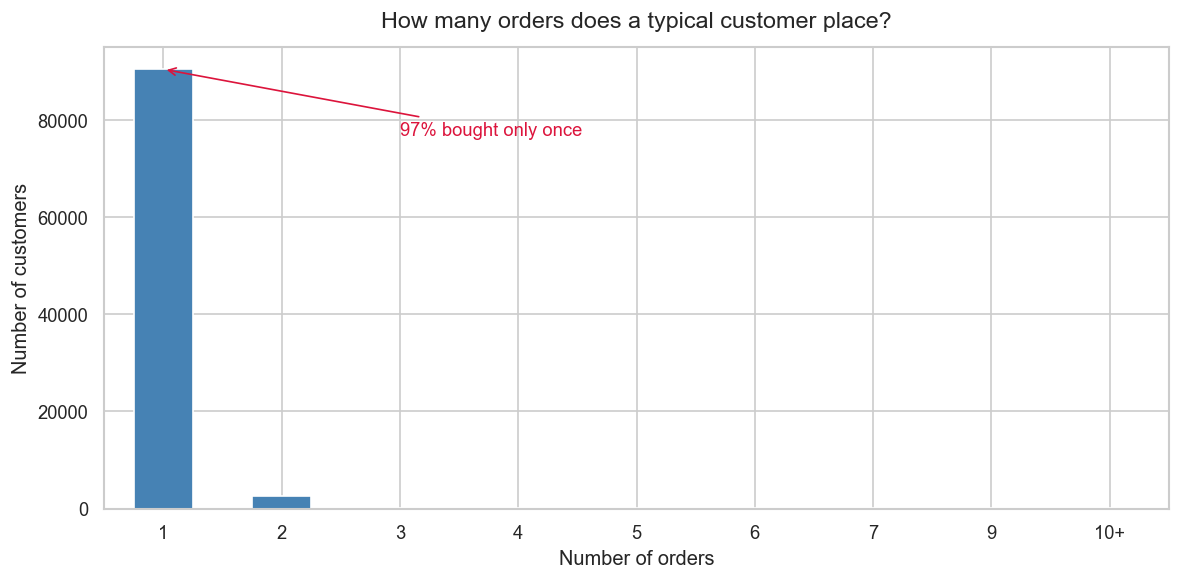

Customers who bought exactly once: 90,557 (97.0%)


In [22]:
purchase_counts = (
    orders_enriched
    .groupby('customer_unique_id')['order_id']
    .count()
)

fig, ax = plt.subplots()

(purchase_counts.clip(upper=10)
                .value_counts()
                .sort_index()
                .plot(kind='bar', ax=ax, color='steelblue', edgecolor='white'))

ax.set_title('How many orders does a typical customer place?', fontsize=14, pad=12)
ax.set_xlabel('Number of orders', fontsize=12)
ax.set_ylabel('Number of customers', fontsize=12)
tick_vals = purchase_counts.clip(upper=10).value_counts().sort_index().index
ax.set_xticks(range(len(tick_vals)))
ax.set_xticklabels(['10+' if v == 10 else str(v) for v in tick_vals], rotation=0)

total = len(purchase_counts)
one_time = (purchase_counts == 1).sum()
ax.annotate(
    f'{one_time/total:.0%} bought only once',
    xy=(0, one_time), xytext=(2, one_time * 0.85),
    arrowprops=dict(arrowstyle='->', color='crimson'),
    color='crimson', fontsize=11
)

plt.tight_layout()
plt.savefig('../reports/figures/01_purchase_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Customers who bought exactly once: {one_time:,} ({one_time/total:.1%})")

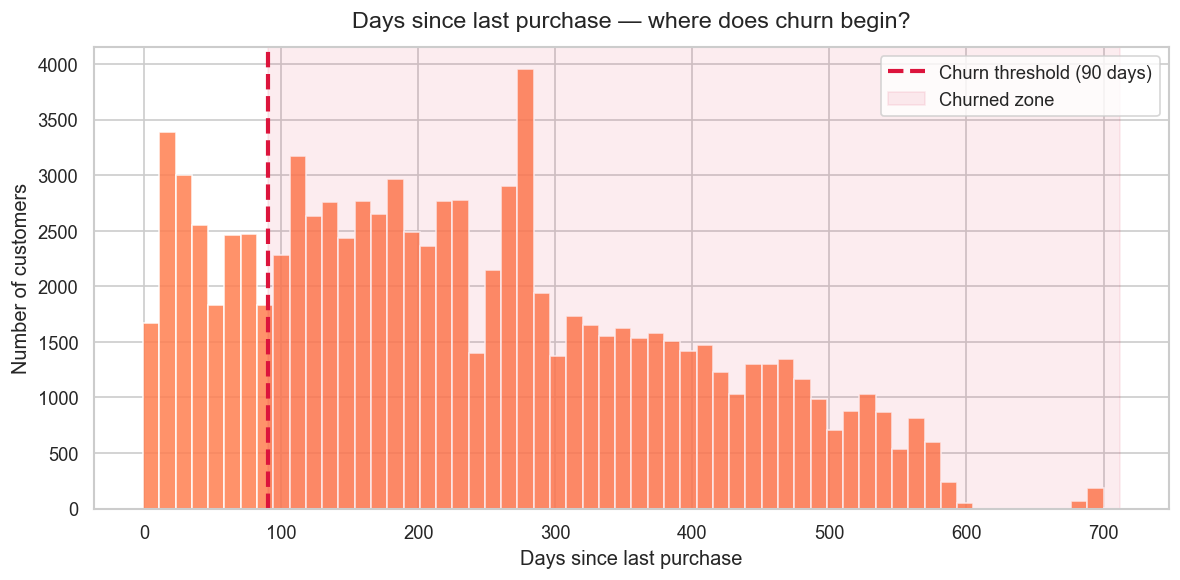

In [23]:
fig, ax = plt.subplots()

customer_stats['days_since_last_purchase'].hist(
    bins=60, ax=ax, color='coral', edgecolor='white', alpha=0.85
)

ax.axvline(x=CHURN_DAYS, color='crimson', linewidth=2.5,
           linestyle='--', label=f'Churn threshold ({CHURN_DAYS} days)')
ax.axvspan(CHURN_DAYS, customer_stats['days_since_last_purchase'].max(),
           alpha=0.08, color='crimson', label='Churned zone')

ax.set_title('Days since last purchase — where does churn begin?', fontsize=14, pad=12)
ax.set_xlabel('Days since last purchase', fontsize=12)
ax.set_ylabel('Number of customers', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/02_days_since_purchase.png', dpi=150, bbox_inches='tight')
plt.show()

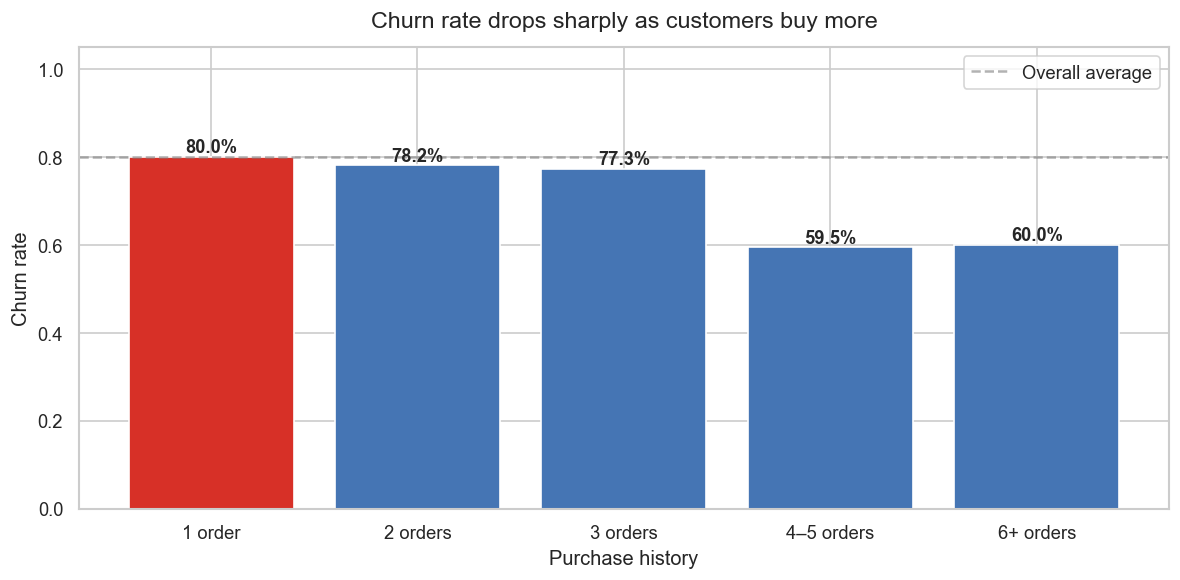

In [24]:
churn_by_freq = (
    customer_stats
    .assign(order_bucket=pd.cut(
        customer_stats['total_orders'],
        bins=[0, 1, 2, 3, 5, 100],
        labels=['1 order', '2 orders', '3 orders', '4–5 orders', '6+ orders']
    ))
    .groupby('order_bucket', observed=True)['churned']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots()

bars = ax.bar(
    churn_by_freq['order_bucket'],
    churn_by_freq['churned'],
    color=['#d73027' if r > 0.8 else '#4575b4' for r in churn_by_freq['churned']],
    edgecolor='white'
)

for bar, rate in zip(bars, churn_by_freq['churned']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{rate:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Churn rate drops sharply as customers buy more', fontsize=14, pad=12)
ax.set_xlabel('Purchase history', fontsize=12)
ax.set_ylabel('Churn rate', fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(y=customer_stats['churned'].mean(), color='gray',
           linestyle='--', alpha=0.6, label='Overall average')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/03_churn_by_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

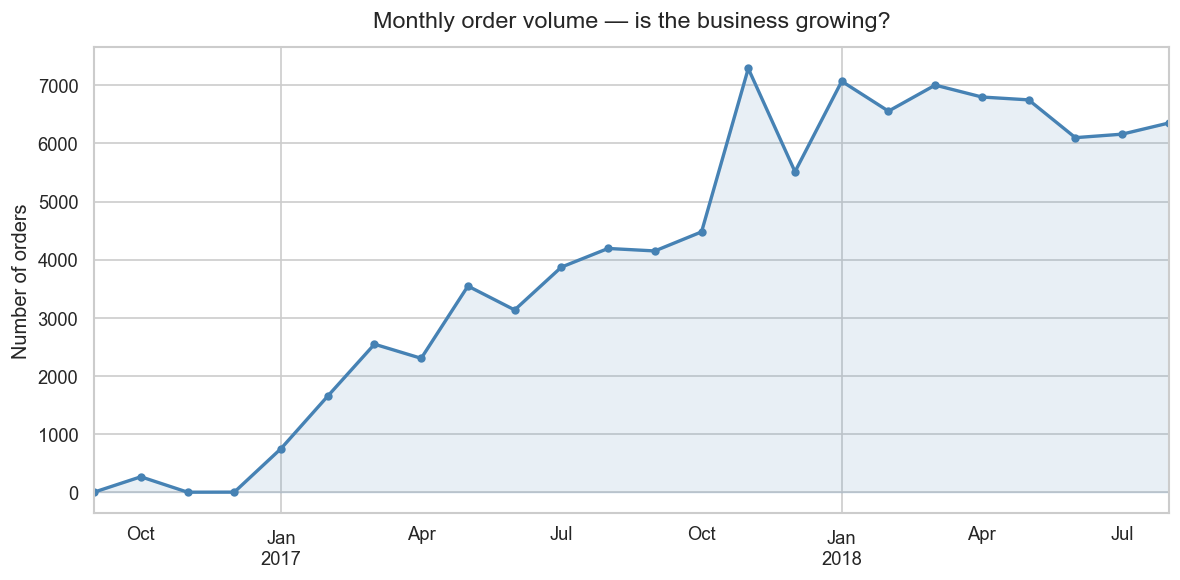

Peak month: November 2017 — 7,289 orders


In [25]:
monthly_orders = (
    orders_enriched
    .set_index('order_purchase_timestamp')
    .resample('ME')['order_id']
    .count()
)

fig, ax = plt.subplots()

monthly_orders.plot(ax=ax, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_orders.index, monthly_orders.values, alpha=0.12, color='steelblue')

ax.set_title('Monthly order volume — is the business growing?', fontsize=14, pad=12)
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Number of orders', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/04_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

peak = monthly_orders.idxmax()
print(f"Peak month: {peak.strftime('%B %Y')} — {monthly_orders.max():,} orders")